# Quantized CNN Training for Posture Classification (HGQ2-based QAT)

**Architecture**
- 3 QConv2D layers with QBatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: QDense(NUM_CLASSES) + QSoftmax

**Quantization Strategy (HGQ2)**
- Automatic bitwidth optimization via gradient descent
- `kbi` quantizer for weights (SAT_SYM overflow)
- `kif` quantizer for activations (WRAP overflow)
- Effective Bit-Operations (EBOPs) tracking for resource estimation

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 15
- Max epochs: 50

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras
from keras import optimizers

# TensorFlow
import tensorflow as tf

# Package imports
from neuroposasic import (
    load_dataset,
    preprocess_data,
    create_quantized_model,
    get_callbacks,
    train_model,
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
)

# HGQ2 quantization-aware training
from hgq.config import LayerConfigScope, QuantizerConfigScope
from hgq.utils import trace_minmax

# hls4ml for hardware conversion
import hls4ml

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

I0000 00:00:1777064554.679198  261237 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Check GPU
print(tf.config.list_physical_devices('GPU'))

# FP32 tuned model path for QAT initialization
FP32_MODEL_PATH = 'output/posture_classifier_base.keras'


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (40325, 64), labels: (40325,)
  Val:   (20162, 64), labels: (20162,)
  Test:  (40326, 64), labels: (40326,)


### Preprocessing

In [4]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)

Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (40325, 8, 8, 1)
  Val:   (20162, 8, 8, 1)
  Test:  (40326, 8, 8, 1)

Data range: [0.0000, 235.8969]
Data dtype: float32


## Configuration

In [5]:
# Define callbacks using package function
callbacks = get_callbacks(model_name='qat', patience=15, track_ebops=True)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint
  - FreeEBOPs


## Quantized Model

HGQ2 Quantization Configuration

HGQ2 uses **gradient-based automatic bitwidth optimization**. Key configuration:

- **`kbi` quantizer** for weights: Optimizes bit-width + integer bits with symmetric saturation overflow
- **`kif` quantizer** for activations (datalane): Optimizes integer bits for data range with wrap-around overflow
- **`beta0=1e-5`**: Controls EBOP regularization strength (lower = more aggressive quantization)
- **`enable_ebops=True`**: Track Effective Bit-Operations for resource estimation

In [6]:
# ============================================================
# AUTOMATIC BITWIDTH OPTIMIZATION (HGQ2 QAT)
# ============================================================
# Two-stage training:
#   Stage 1: Warmup with very small EBOP penalty (beta0=1e-9)
#   Stage 2: Compression with gradual EBOP penalty
# ============================================================

# Load FP32 tuned model for weight initialization
print("Loading FP32 tuned model for initialization...")
fp32_model = keras.models.load_model(FP32_MODEL_PATH)
print(f"FP32 model loaded: {fp32_model.name}")
fp32_test_loss, fp32_test_acc = fp32_model.evaluate(X_test, y_test, verbose=0)
print(f"FP32 test accuracy: {fp32_test_acc*100:.2f}%")
print()

# ----- STAGE 1: Warmup (very small EBOP penalty) -----
print("=" * 70)
print("STAGE 1: QAT Warmup (beta0=1e-9, 15 epochs)")
print("=" * 70)

with (
    # Weight quantizer: kbi type with symmetric saturation
    QuantizerConfigScope(
        q_type='kbi',
        place='weight',
         k0=False,        # Disable automatic bitwidth
        b0=8, i0=4,      # Fixed 8-bit weights (4 integer + 4 fractional)
        overflow_mode='SAT_SYM',
        round_mode='RND'
    ),
    # Activation quantizer: kif type with wrap-around
    QuantizerConfigScope(
        q_type='kif',
        place='datalane',
        k0=False,        # Disable automatic bitwidth
        i0=4, f0=4,      # Fixed 8-bit activations (4 integer + 4 fractional)
        overflow_mode='WRAP',
        round_mode='RND'
    ),
    # Layer configuration: enable EBOP tracking with very weak penalty
    LayerConfigScope(
        enable_ebops=True,
        beta0=1e-9
    ),
):
    model_qat = create_quantized_model(num_classes=NUM_CLASSES)
    # Transfer weights from converged FP32 model

# Transfer weights layer-by-layer (QAT has extra quantizer params)
print("Transferring FP32 weights to QAT model...")

fp32_layers = [
    l for l in fp32_model.layers
    if l.__class__.__name__ in ("Conv2D", "Dense")
]
qat_layers = [
    l for l in model_qat.layers
    if l.__class__.__name__ in ("QConv2D", "QDense")
]

for fp32_layer, qat_layer in zip(fp32_layers, qat_layers):
    fp32_w = fp32_layer.get_weights()
    qat_w = qat_layer.get_weights()
    # Replace kernel weights, keep quantizer params untouched
    new_w = fp32_w + qat_w[len(fp32_w):]
    qat_layer.set_weights(new_w)
    print(f"  {fp32_layer.name} -> {qat_layer.name}")

print("Weight transfer complete.")

model_qat.summary()
check_layer_trainable_params(model_qat)


Loading FP32 tuned model for initialization...


I0000 00:00:1777064556.665056  261237 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5054 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


FP32 model loaded: posture_classifier_base


I0000 00:00:1777064557.635325  261299 service.cc:153] XLA service 0x7f5d68031670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777064557.635355  261299 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777064557.648792  261299 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777064557.709909  261299 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777064558.881164  261299 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


FP32 test accuracy: 87.09%

STAGE 1: QAT Warmup (beta0=1e-9, 15 epochs)
Transferring FP32 weights to QAT model...
  conv_1 -> qconv_1
  conv_2 -> qconv_2
  conv_3 -> qconv_3
  output -> output
Weight transfer complete.


Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 6, 6, 16)       │           771 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 16)       │        10,947 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 24)       │        14,595 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 1, 1, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 24)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           376 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,689 (84.04 KB)

 Trainable params: 18,854 (73.65 KB)

 Non-trainable params: 7,835 (10.39 KB)

In [7]:
# Compile for Stage 1
model_qat.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks for Stage 1
callbacks_stage1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_qat_stage1.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
]

# Train Stage 1
history_stage1 = model_qat.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks_stage1,
    verbose=1
)

print("\nStage 1 complete.")
print(f"Best val accuracy: {max(history_stage1.history['val_accuracy'])*100:.2f}%")


Epoch 1/50


I0000 00:00:1777064564.493113  261300 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13077__.51


1254/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3493 - loss: 33.3455

I0000 00:00:1777064573.071778  261298 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13077__.51


1261/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3493 - loss: 33.2336
Epoch 1: val_accuracy improved from None to 0.39614, saving model to best_qat_stage1.keras

Epoch 1: finished saving model to best_qat_stage1.keras
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.3632 - loss: 13.1619 - val_accuracy: 0.3961 - val_loss: 3.1271 - learning_rate: 0.0010
Epoch 2/50
1237/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3864 - loss: 3.8097
Epoch 2: val_accuracy did not improve from 0.39614
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3887 - loss: 3.0565 - val_accuracy: 0.3266 - val_loss: 1.9118 - learning_rate: 0.0010
Epoch 3/50
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3976 - loss: 1.8146
Epoch 3: val_accuracy improved from 0.39614 to 0.43522, saving model to best_qat_stage1.keras

Epoch 3: finished saving model to best_qat_stage1.keras
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3904 - loss: 1.7499 - val_accuracy: 0.4352 - val_l

### Training

Two-stage QAT training:
1. **Stage 1** (15 epochs): Warmup with very small EBOP penalty to let the model adapt to quantization.
2. **Stage 2** (15 epochs): Compression with gradual EBOP penalty to reduce bitwidth.




STAGE 2: QAT Compression (beta0=1e-7, 15 epochs)
Loading best weights from Stage 1...
Epoch 1/50


I0000 00:00:1777064704.570853  261299 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_377959__.51


1237/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6316 - loss: 0.8320

I0000 00:00:1777064709.212152  261299 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_377959__.51


1261/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6317 - loss: 0.8318
Epoch 1: val_accuracy improved from None to 0.63337, saving model to best_qat_stage2.keras

Epoch 1: finished saving model to best_qat_stage2.keras
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.6384 - loss: 0.8239 - val_accuracy: 0.6334 - val_loss: 0.8126 - learning_rate: 5.0000e-04
Epoch 2/50
1255/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6194 - loss: 0.8639
Epoch 2: val_accuracy did not improve from 0.63337
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6152 - loss: 0.8663 - val_accuracy: 0.6280 - val_loss: 0.8425 - learning_rate: 5.0000e-04
Epoch 3/50
1248/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6210 - loss: 0.8473
Epoch 3: val_accuracy did not improve from 0.63337
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6266 - loss: 0.8384 - val_accuracy: 0.6278 - val_loss: 0.8319 - learning_rate: 5.0000e-04
Epoch 4/50
1244/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

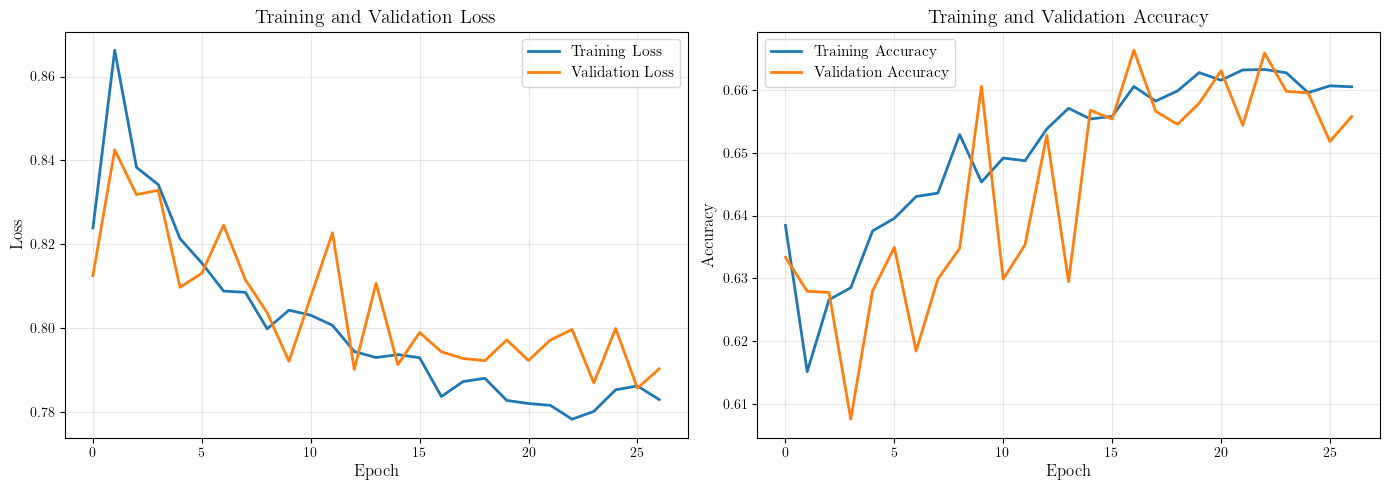

In [8]:
# ----- STAGE 2: Compression (gradual EBOP penalty) -----
print("\n" + "=" * 70)
print("STAGE 2: QAT Compression (beta0=1e-7, 15 epochs)")
print("=" * 70)

# Load best weights from Stage 1
print("Loading best weights from Stage 1...")
model_qat.load_weights('best_qat_stage1.keras')

with (
    QuantizerConfigScope(
        q_type='kbi',
        place='weight',
         k0=False,        # Disable automatic bitwidth
        b0=8, i0=4,      # Fixed 8-bit weights (4 integer + 4 fractional)
        overflow_mode='SAT_SYM',
        round_mode='RND'
    ),
    QuantizerConfigScope(
        q_type='kif',
        place='datalane',
        k0=False,        # Disable automatic bitwidth
        i0=4, f0=4,      # Fixed 8-bit activations (4 integer + 4 fractional)
        overflow_mode='WRAP',
        round_mode='RND'
    ),
    LayerConfigScope(
        enable_ebops=True,
        beta0=1e-7
    ),
):
    pass  # Scopes apply to existing model quantizers

# Re-compile with lower learning rate for fine-tuning
model_qat.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks for Stage 2
callbacks_stage2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_qat_stage2.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
]

# Train Stage 2
history_stage2 = model_qat.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks_stage2,
    verbose=1
)

print("\nStage 2 complete.")
print(f"Best val accuracy: {max(history_stage2.history['val_accuracy'])*100:.2f}%")

plot_training_history(history_stage2, model_name='posture_classifier_qat', save=True)

### Post-Training: Trace Min-Max

**Critical step before hls4ml conversion.**

When using `WRAP` overflow mode for activations (datalane), HGQ2 needs to know the min/max values of each layer's activations to determine the required integer bits. This is done by tracing the model on representative data.

**Important:** Use representative data (test set) for tracing, not training data.

In [9]:
# Trace min/max values for WRAP overflow mode
# This determines the integer bits needed for each activation layer
print("Tracing min/max values for activation quantization...")
print("Using test set for representative statistics.\n")

# Use subset for tracing (faster)
trace_samples = min(5000, X_test.shape[0])
trace_minmax(model_qat, X_test[:trace_samples], verbose=True)

print("\nMin/max tracing complete.")
print("Integer bits for each layer are now determined.")

Tracing min/max values for activation quantization...
Using test set for representative statistics.



qconv_1: 46173
qconv_2: 256899
qconv_3: 572542
output : 3789
Total: 879403

Min/max tracing complete.
Integer bits for each layer are now determined.


## Model Evaluation

In [10]:
# Load best quantized model
print("Loading best quantized model (Stage 2)...")
model_qat.load_weights('best_qat_stage2.keras')
print("Best model loaded successfully.\n")

Loading best quantized model (Stage 2)...
Best model loaded successfully.



In [11]:
# Detailed classification report
class_report_metric(model_qat, X_test, y_test, class_names)


Accuracy Report for `posture_classifier_qat`:
  Loss: 0.7940
  Accuracy: 66.72%

Classification Report for `posture_classifier_qat`:
              precision    recall  f1-score   support

   lateral_L     0.7141    0.6829    0.6982     17406
   lateral_R     0.6099    0.7089    0.6557     12678
      supine     0.6742    0.5887    0.6285     10242

    accuracy                         0.6672     40326
   macro avg     0.6661    0.6602    0.6608     40326
weighted avg     0.6712    0.6672    0.6671     40326



## hls4ml Conversion

Convert the quantized model to HLS (High-Level Synthesis) code for FPGA deployment.

In [12]:
# hls4ml configuration
print("Configuring hls4ml conversion...\n")

# HLS configuration
# Note: HGQ2 models automatically invoke model-wise precision propagation
# Do NOT manually set precision config unless you know what you're doing
hls_config = {
    'Model': {
        'ReuseFactor': 1,  # Maximum parallelism
        'Strategy': 'Latency',  # Minimize latency
    }
}

# FPGA backend configuration
backend = 'Vitis'  # Recommended over Vivado for better Vivado HLS compatibility
io_type = 'io_parallel'  # Use io_stream for larger models

print(f"HLS Backend: {backend}")
print(f"I/O Type: {io_type}")
print(f"Reuse Factor: {hls_config['Model']['ReuseFactor']}")
print(f"Strategy: {hls_config['Model']['Strategy']}")
print("\nNote: Precision is automatically inferred from HGQ2 model.")

Configuring hls4ml conversion...

HLS Backend: Vitis
I/O Type: io_parallel
Reuse Factor: 1
Strategy: Latency

Note: Precision is automatically inferred from HGQ2 model.


In [13]:
# Convert model to HLS
print("\nConverting quantized model to HLS...\n")

output_dir = 'hls4ml_posture_cnn'

hls_model = hls4ml.converters.convert_from_keras_model(
    model_qat,
    input_shapes=X_test[0:1].shape,
    hls_config=hls_config,
    output_dir=output_dir,
    backend=backend,
    io_type=io_type
)

print(f"\nHLS model created successfully.")
print(f"Output directory: {output_dir}")


Converting quantized model to HLS...



AssertionError: 

In [ ]:
# Write HLS code to disk
print("Writing HLS C++ code to disk...")
hls_model.write()
print(f"HLS code written to {output_dir}/")
print(f"  - firmware/ : C++ source files")
print(f"  - project/ : Vivado/Vitis project files")

In [ ]:
# Compile HLS model for bit-exact simulation
print("\nCompiling HLS model for simulation...")
hls_model.compile()
print("HLS model compiled successfully.")

In [ ]:
# Verify bit-exactness between Keras and HLS models
print("\nVerifying bit-exactness between Keras and HLS models...\n")

# Use subset of test data for verification
n_samples = min(100, X_test.shape[0])

keras_predictions = model_qat.predict(X_test[:n_samples])
hls_predictions = hls_model.predict(X_test[:n_samples])

# Check for mismatches
mismatches = np.sum(keras_predictions != hls_predictions)
total_values = np.prod(keras_predictions.shape)
match_percentage = (1 - mismatches / total_values) * 100

print(f"Verification Results:")
print(f"  Samples tested: {n_samples}")
print(f"  Mismatches: {mismatches} / {total_values} values")
print(f"  Match percentage: {match_percentage:.4f}%")

if mismatches == 0:
    print("\n✓ Perfect bit-exact match between Keras and HLS models!")
else:
    print(f"\n⚠ Minor mismatches detected ({mismatches} values).")
    print("  This may be due to floating-point precision differences.")
    print("  Verify that accuracy is maintained.")

In [ ]:
# Compare HLS predictions with true labels
hls_pred_classes = np.argmax(hls_predictions, axis=1)
hls_accuracy = np.mean(hls_pred_classes == y_true[:n_samples])

print(f"\nHLS Model Accuracy (on {n_samples} samples): {hls_accuracy:.4f}")
print(f"Keras Model Accuracy (on {n_samples} samples): {np.mean(np.argmax(keras_predictions, axis=1) == y_true[:n_samples]):.4f}")